# Examen Final Simulación de Procesos Financieros

**Gonzalo Cano Padilla**

## Ejercicio 1: Análisis de Estrategias de Opciones con Datos Reales (JPM)

Construimos dos estrategias de opciones usando contratos reales de JPMorgan Chase (JPM):

| # | Estrategia | Descripción breve |
|---|-----------|-------------------|
| 1 | **Bull Call Spread** | Apuesta alcista moderada con riesgo acotado |
| 2 | **Long Straddle** | Apuesta a volatilidad, neutral a la dirección |

Para cada una: diagrama de payoff con break-even y límites de ganancia/pérdida, Griegas individuales y netas calculadas con Black-Scholes, y análisis de condición de mercado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

def bs_greeks(S, K, T, r, sigma, tipo='call'):
    if T <= 0 or sigma <= 0:
        return dict(delta=0, gamma=0, theta=0, vega=0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100  
    if tipo == 'call':
        delta = norm.cdf(d1)
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r*T) * norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r*T) * norm.cdf(-d2)) / 365
    return dict(delta=delta, gamma=gamma, theta=theta, vega=vega)

def closest_strike(df, target):

    return df.iloc[(df['strike'] - target).abs().argsort()[:1]]

### 1. Descarga de datos — JPM

Descargamos el precio spot y la cadena de opciones vigente de JPMorgan Chase (JPM). Seleccionamos un vencimiento con aproximadamente 40–60 días al vencimiento para tener suficiente valor temporal y liquidez.

In [2]:
jpm      = yf.Ticker('JPM')
spot     = jpm.history(period='5d')['Close'].iloc[-1]
expiries = jpm.options

print(f'Precio actual de JPM: USD {spot:.2f}\n')
print('Vencimientos disponibles:')
for i, e in enumerate(expiries[:10]):
    print(f'  [{i}] {e}')

expiry = expiries[2]
chain  = jpm.option_chain(expiry)
calls  = chain.calls.copy()
puts   = chain.puts.copy()

T = max((datetime.strptime(expiry, '%Y-%m-%d') - datetime.today()).days / 365, 1/365)
r = 0.053  # Fed Funds rate aprox.

calls['mid'] = np.where(calls['bid'] > 0, (calls['bid'] + calls['ask'])/2, calls['lastPrice'])
puts['mid']  = np.where(puts['bid'] > 0,  (puts['bid']  + puts['ask'])/2,  puts['lastPrice'])

print(f'\nVencimiento seleccionado: {expiry}')
print(f'Dias al vencimiento     : {round(T*365)}')

rng = 0.08
mask_c = (calls['strike'] >= spot*(1-rng)) & (calls['strike'] <= spot*(1+rng))
mask_p = (puts['strike']  >= spot*(1-rng)) & (puts['strike']  <= spot*(1+rng))

print('\nCalls near-the-money:')
print(calls[mask_c][['strike','mid','impliedVolatility','volume']].reset_index(drop=True).to_string())
print('\nPuts near-the-money:')
print(puts[mask_p][['strike','mid','impliedVolatility','volume']].reset_index(drop=True).to_string())

Precio actual de JPM: USD 300.25

Vencimientos disponibles:
  [0] 2026-05-15
  [1] 2026-05-22
  [2] 2026-05-29
  [3] 2026-06-05
  [4] 2026-06-12
  [5] 2026-06-18
  [6] 2026-06-26
  [7] 2026-07-17
  [8] 2026-08-21
  [9] 2026-09-18

Vencimiento seleccionado: 2026-05-29
Dias al vencimiento     : 15

Calls near-the-money:
   strike     mid  impliedVolatility  volume
0   280.0  22.100           0.411627    15.0
1   285.0  17.725           0.378241     2.0
2   290.0  13.900           0.347602    16.0
3   295.0  10.250           0.315681     2.0
4   300.0   7.125           0.296150    47.0
5   305.0   4.700           0.288032    61.0
6   310.0   2.950           0.271125    21.0
7   315.0   1.630           0.262214   607.0
8   320.0   1.000           0.272224   156.0

Puts near-the-money:
   strike     mid  impliedVolatility  volume
0   280.0   1.010           0.295295   100.0
1   285.0   1.640           0.280891    28.0
2   290.0   2.655           0.274543    18.0
3   295.0   4.175           

---

### Estrategia 1: Bull Call Spread

**Construcción:** comprar una call ATM (K1, en o cerca del dinero) y vender una call OTM (K2, ~5% más arriba). Ambas con el mismo vencimiento. El resultado es un débito neto: pagamos menos que una call sola porque la call vendida financia parte del costo.

In [3]:
# Seleccion de contratos
K1_row   = closest_strike(calls, spot)
K1       = float(K1_row['strike'].values[0])
K1_price = float(K1_row['mid'].values[0])
K1_iv    = float(K1_row['impliedVolatility'].values[0])

K2_row   = closest_strike(calls, spot * 1.05)
K2       = float(K2_row['strike'].values[0])
K2_price = float(K2_row['mid'].values[0])
K2_iv    = float(K2_row['impliedVolatility'].values[0])

prima    = K1_price - K2_price   # debito neto pagado
max_gain = (K2 - K1) - prima
max_loss = prima
be       = K1 + prima

print('--------------------------------------------------')
print('  BULL CALL SPREAD (JPM)')
print('--------------------------------------------------')
print(f'  Comprar  call  K1 = USD {K1:.0f}   prima: USD {K1_price:.2f}')
print(f'  Vender   call  K2 = USD {K2:.0f}   prima: USD {K2_price:.2f}')
print('--------------------------------------------------')
print(f'  Debito neto pagado  : USD {prima:.2f}')
print(f'  Break-even          : USD {be:.2f}')
print(f'  Ganancia maxima     : USD {max_gain:.2f}  (cuando S >= USD {K2:.0f})')
print(f'  Perdida maxima      : USD {max_loss:.2f}  (cuando S <= USD {K1:.0f})')
print('--------------------------------------------------')

--------------------------------------------------
  BULL CALL SPREAD (JPM)
--------------------------------------------------
  Comprar  call  K1 = USD 300   prima: USD 7.12
  Vender   call  K2 = USD 315   prima: USD 1.63
--------------------------------------------------
  Debito neto pagado  : USD 5.50
  Break-even          : USD 305.50
  Ganancia maxima     : USD 9.50  (cuando S >= USD 315)
  Perdida maxima      : USD 5.50  (cuando S <= USD 300)
--------------------------------------------------


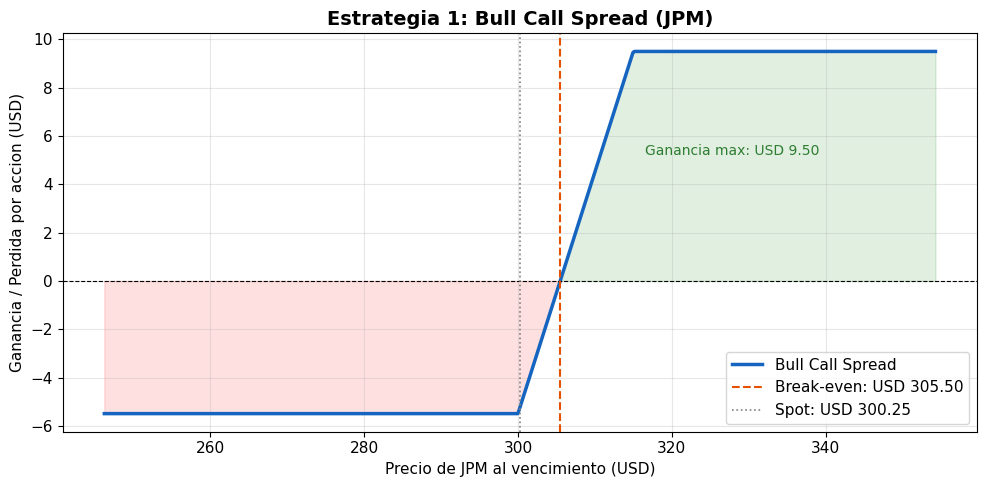

In [4]:
S_range = np.linspace(spot * 0.82, spot * 1.18, 600)
pnl_bcs = (np.maximum(S_range - K1, 0) - K1_price) + \
          (-np.maximum(S_range - K2, 0) + K2_price)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_range, pnl_bcs, color='#1565C0', lw=2.5, label='Bull Call Spread')
ax.axhline(0,    color='black',   lw=0.8, ls='--')
ax.axvline(be,   color='#E65100', lw=1.5, ls='--', label=f'Break-even: USD {be:.2f}')
ax.axvline(spot, color='gray',    lw=1.2, ls=':',  label=f'Spot: USD {spot:.2f}')
ax.fill_between(S_range, pnl_bcs, 0, where=(pnl_bcs > 0), color='green', alpha=0.12)
ax.fill_between(S_range, pnl_bcs, 0, where=(pnl_bcs < 0), color='red',   alpha=0.12)
ax.annotate(f'Ganancia max: USD {max_gain:.2f}',
            xy=(K2 * 1.005, max_gain * 0.55), color='#2E7D32', fontsize=10)
ax.annotate(f'Perdida max: -USD {max_loss:.2f}',
            xy=(spot * 0.835, -max_loss * 2.0), color='#C62828', fontsize=10)
ax.set_title('Estrategia 1: Bull Call Spread (JPM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio de JPM al vencimiento (USD)')
ax.set_ylabel('Ganancia / Perdida por accion (USD)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [5]:
# Griegas con Black-Scholes
g1 = bs_greeks(spot, K1, T, r, K1_iv, 'call')   # long call K1
g2 = bs_greeks(spot, K2, T, r, K2_iv, 'call')   # short call K2

df_bcs = pd.DataFrame({
    'Posicion' : ['+1 (long)',  '-1 (short)', 'NETO'],
    'Delta'    : [ g1['delta'],  -g2['delta'],  g1['delta']  - g2['delta']],
    'Gamma'    : [ g1['gamma'],  -g2['gamma'],  g1['gamma']  - g2['gamma']],
    'Theta'    : [ g1['theta'],  -g2['theta'],  g1['theta']  - g2['theta']],
    'Vega'     : [ g1['vega'],   -g2['vega'],   g1['vega']   - g2['vega']],
}, index=[f'Call K={K1:.0f}', f'Call K={K2:.0f}', 'Portafolio'])

print('Griegas individuales y netas — Bull Call Spread\n')
print(df_bcs.round(4).to_string())

Griegas individuales y netas — Bull Call Spread

              Posicion   Delta   Gamma   Theta    Vega
Call K=300   +1 (long)  0.5319  0.0221 -0.2610  0.2420
Call K=315  -1 (short) -0.2020 -0.0176  0.1584 -0.1714
Portafolio        NETO  0.3300  0.0044 -0.1027  0.0706


#### ¿Cuándo tiene sentido usar el Bull Call Spread?

Esta estrategia funciona cuando creemos que JPM va a subir, pero de forma moderada — no esperamos un salto dramático, sino un movimiento gradual hacia arriba. Tampoco queremos pagar toda la prima de una call sola, así que la financiamos parcialmente vendiendo una call más arriba del mercado.

**Dirección esperada:** alcista moderada. Queremos que JPM supere el break-even antes del vencimiento, pero no necesitamos que se dispare — con que llegue al strike vendido ya capturamos la ganancia máxima.

**Volatilidad:** preferimos que se mantenga estable o que baje. Si la volatilidad sube mucho después de que entramos, la call que vendimos también sube de valor, lo que limita nuestra ganancia y puede hacer que la posición no avance como esperábamos.

**Las Griegas nos lo confirman:**

- **Delta neto positivo:** el portafolio gana valor cuando JPM sube. Su magnitud (entre 0 y 1) confirma que la apuesta es moderada y controlada — no tan agresiva como comprar una call sola, que tendría un delta mayor.

- **Vega neta negativa (o muy cercana a cero):** al haber vendido la call de K2, el portafolio casi no se beneficia si la volatilidad implícita sube. Los dos contratos reaccionan de forma opuesta ante cambios de vol y casi se cancelan entre sí. Esto confirma que el Bull Call Spread es una estrategia principalmente de dirección, no de volatilidad.

---

### Estrategia 2: Long Straddle

**Construcción:** comprar una call ATM y una put ATM con el mismo strike y vencimiento. Pagamos prima por los dos lados, pero a cambio ganamos sin importar la dirección del movimiento, siempre que sea suficientemente grande.

In [6]:
# Seleccion de contratos: mismo strike ATM para call y put
K_s = float(closest_strike(calls, spot)['strike'].values[0])

call_row = closest_strike(calls, K_s)
c_price  = float(call_row['mid'].values[0])
c_iv     = float(call_row['impliedVolatility'].values[0])

put_row  = closest_strike(puts, K_s)
p_price  = float(put_row['mid'].values[0])
p_iv     = float(put_row['impliedVolatility'].values[0])

prima_s = c_price + p_price
be_up   = K_s + prima_s
be_dn   = K_s - prima_s

print('--------------------------------------------------')
print('  LONG STRADDLE (JPM)')
print('--------------------------------------------------')
print(f'  Comprar  call  K = USD {K_s:.0f}   prima: USD {c_price:.2f}')
print(f'  Comprar  put   K = USD {K_s:.0f}   prima: USD {p_price:.2f}')
print('--------------------------------------------------')
print(f'  Prima total pagada   : USD {prima_s:.2f}')
print(f'  Break-even superior  : USD {be_up:.2f}')
print(f'  Break-even inferior  : USD {be_dn:.2f}')
print(f'  Ganancia maxima      : ilimitada (alza) / hasta USD {K_s:.0f} (baja)')
print(f'  Perdida maxima       : USD {prima_s:.2f}  (si S = USD {K_s:.0f} al vencimiento)')
print('--------------------------------------------------')

--------------------------------------------------
  LONG STRADDLE (JPM)
--------------------------------------------------
  Comprar  call  K = USD 300   prima: USD 7.12
  Comprar  put   K = USD 300   prima: USD 6.18
--------------------------------------------------
  Prima total pagada   : USD 13.30
  Break-even superior  : USD 313.30
  Break-even inferior  : USD 286.70
  Ganancia maxima      : ilimitada (alza) / hasta USD 300 (baja)
  Perdida maxima       : USD 13.30  (si S = USD 300 al vencimiento)
--------------------------------------------------


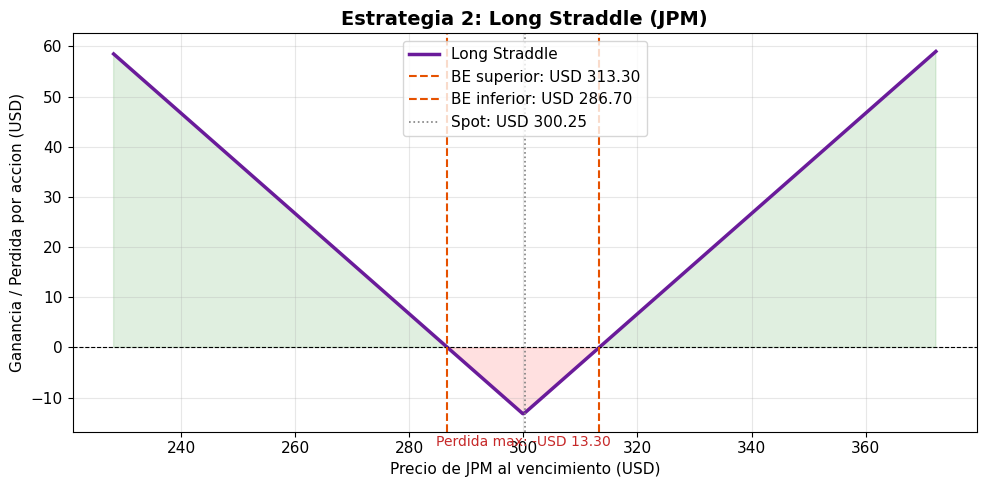

In [7]:
S_range = np.linspace(spot * 0.76, spot * 1.24, 600)
pnl_s   = (np.maximum(S_range - K_s, 0) - c_price) + \
           (np.maximum(K_s - S_range, 0) - p_price)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_range, pnl_s, color='#6A1B9A', lw=2.5, label='Long Straddle')
ax.axhline(0,     color='black',   lw=0.8, ls='--')
ax.axvline(be_up, color='#E65100', lw=1.5, ls='--', label=f'BE superior: USD {be_up:.2f}')
ax.axvline(be_dn, color='#E65100', lw=1.5, ls='--', label=f'BE inferior: USD {be_dn:.2f}')
ax.axvline(spot,  color='gray',    lw=1.2, ls=':',  label=f'Spot: USD {spot:.2f}')
ax.fill_between(S_range, pnl_s, 0, where=(pnl_s > 0), color='green', alpha=0.12)
ax.fill_between(S_range, pnl_s, 0, where=(pnl_s < 0), color='red',   alpha=0.12)
ax.annotate(f'Perdida max: -USD {prima_s:.2f}',
            xy=(K_s, -prima_s * 0.9), color='#C62828', fontsize=10,
            ha='center', xytext=(0, -28), textcoords='offset points')
ax.set_title('Estrategia 2: Long Straddle (JPM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio de JPM al vencimiento (USD)')
ax.set_ylabel('Ganancia / Perdida por accion (USD)')
ax.legend(loc='upper center')
plt.tight_layout()
plt.show()

In [8]:
# Griegas con Black-Scholes
gc = bs_greeks(spot, K_s, T, r, c_iv, 'call')
gp = bs_greeks(spot, K_s, T, r, p_iv, 'put')

df_str = pd.DataFrame({
    'Posicion' : ['+1 (long)', '+1 (long)', 'NETO'],
    'Delta'    : [ gc['delta'],  gp['delta'],  gc['delta'] + gp['delta']],
    'Gamma'    : [ gc['gamma'],  gp['gamma'],  gc['gamma'] + gp['gamma']],
    'Theta'    : [ gc['theta'],  gp['theta'],  gc['theta'] + gp['theta']],
    'Vega'     : [ gc['vega'],   gp['vega'],   gc['vega']  + gp['vega']],
}, index=[f'Call K={K_s:.0f}', f'Put  K={K_s:.0f}', 'Portafolio'])

print('Griegas individuales y netas — Long Straddle\n')
print(df_str.round(4).to_string())

Griegas individuales y netas — Long Straddle

             Posicion   Delta   Gamma   Theta   Vega
Call K=300  +1 (long)  0.5319  0.0221 -0.2610  0.242
Put  K=300  +1 (long) -0.4667  0.0251 -0.1888  0.242
Portafolio       NETO  0.0652  0.0472 -0.4498  0.484


#### ¿Cuándo tiene sentido usar el Long Straddle?

Esta estrategia funciona cuando no tienes convicción sobre la dirección del mercado, pero sí estás seguro de que JPM va a moverse fuerte en las próximas semanas. Un ejemplo clásico sería justo antes de que JPM reporte resultados trimestrales, o cuando hay una decisión de tasas de la Fed que puede afectar mucho a los bancos. No importa si sube o baja — lo que necesitas es que el movimiento sea lo suficientemente grande como para recuperar la prima total que pagaste.

**Dirección esperada:** neutral. No apostamos ni al alza ni a la baja. Le ganamos tanto si JPM cae fuerte como si sube fuerte, siempre que supere alguno de los dos break-evens.

**Volatilidad:** necesitamos que sea alta, o que aumente después de que entramos. Si JPM se queda quieto cerca del strike durante todo el período, perdemos toda la prima.

**Las Griegas nos lo confirman:**

- **Delta neto cercano a cero:** compramos una call con delta ≈ +0.5 y una put con delta ≈ −0.5, y los dos casi se anulan entre sí. Esto confirma que la estrategia es completamente neutral a la dirección en el momento de entrada — no estamos apostando ni para arriba ni para abajo.

- **Theta neto negativo (pronunciado):** este es el mayor riesgo del straddle. Al comprar dos opciones sin vender ninguna, el paso del tiempo nos perjudica todos los días que JPM no se mueve. El theta negativo nos dice que si el precio se queda pegado al strike, perdemos valor constantemente. Por eso esta estrategia se construye poco antes del evento esperado, no meses antes.

---

## Ejercicio 2: Valuación de Opciones Exóticas con Monte Carlo

Valuamos cuatro tipos de opciones sobre JPMorgan Chase (JPM) usando simulación de Monte Carlo con 50,000 trayectorias GBM. Las primeras dos sirven de referencia (europeas estándar); las otras dos son opciones exóticas cuyo payoff depende de la trayectoria completa del precio.

### Parámetros utilizados

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| Activo | JPM | Mismo activo del ejercicio 1, altamente líquido |
| S0 | Precio de cierre histórico (2025-01-01) | Último precio disponible del período |
| K | Redondeado al múltiplo de 5 más cercano a S0 | Strike ATM, el más común en la práctica |
| σ | Volatilidad histórica diaria anualizada (2023–2025) | Estimación basada en datos recientes de dos años |
| r | 5.3% | Fed Funds rate aproximado vigente |
| T | 0.5 años (6 meses) | Horizonte razonable para ver movimiento significativo |
| B | ~S0 × 1.15 | La barrera está 15% arriba del spot. Suficientemente lejos para que no se toque en escenarios moderados, pero lo bastante cerca para que sí sea alcanzada en los escenarios alcistas fuertes que serían los más rentables para el call |

In [ ]:
hist  = yf.Ticker('JPM').history(start='2023-01-01', end='2025-01-01')['Close']
S0    = float(hist.iloc[-1])
sigma = float(hist.pct_change().dropna().std() * np.sqrt(252))

K  = round(S0 / 5) * 5        # strike ATM redondeado al multiplo de 5
r  = 0.053                      # tasa libre de riesgo (Fed Funds)
T  = 0.5                        # 6 meses
B  = round(S0 * 1.15 / 5) * 5  # barrera up-and-out 15% sobre el spot
N  = 50000
M  = int(T * 252)               # pasos diarios

print(f'S0    = USD {S0:.2f}')
print(f'K     = USD {K:.2f}')
print(f'sigma = {sigma:.4f}  (vol historica anualizada 2023-2025)')
print(f'r     = {r}  (Fed Funds rate)')
print(f'T     = {T} anios (6 meses)')
print(f'B     = USD {B:.2f}  (barrera up-and-out, ~15% sobre el spot)')
print(f'N     = {N:,} trayectorias  |  M = {M} pasos diarios')

S0    = USD 232.50
K     = USD 230.00
sigma = 0.2217  (vol historica anualizada 2023-2025)
r     = 0.053  (Fed Funds rate)
T     = 0.5 anios (6 meses)
B     = USD 265.00  (barrera up-and-out, ~15% sobre el spot)
N     = 50,000 trayectorias  |  M = 126 pasos diarios


In [10]:
np.random.seed(42)

# Simulacion GBM — trayectorias completas
dt      = T / M
Z       = np.random.normal(0, 1, (N, M))
log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
paths   = S0 * np.exp(np.cumsum(log_inc, axis=1))   # shape (N, M)

ST       = paths[:, -1]          # precio final de cada trayectoria
promedio = np.mean(paths, axis=1) # promedio aritmetico de cada trayectoria
max_path = np.max(paths, axis=1)  # maximo alcanzado en cada trayectoria
activa   = max_path < B           # True si la barrera nunca fue tocada

In [11]:
# Payoffs al vencimiento
payoff_call    = np.maximum(ST - K, 0)
payoff_put     = np.maximum(K - ST, 0)
payoff_asian   = np.maximum(promedio - K, 0)
payoff_barrier = np.maximum(ST - K, 0) * activa

# Precios descontados
precio_call    = np.exp(-r * T) * np.mean(payoff_call)
precio_put     = np.exp(-r * T) * np.mean(payoff_put)
precio_asian   = np.exp(-r * T) * np.mean(payoff_asian)
precio_barrier = np.exp(-r * T) * np.mean(payoff_barrier)

# Tabla comparativa
tabla = pd.DataFrame({
    'Opcion'      : ['Call europea', 'Put europea', 'Asian call', 'Up-and-out call'],
    'Precio (USD)': [f'{p:.4f}' for p in [precio_call, precio_put, precio_asian, precio_barrier]],
    '% sin valor' : [f'{np.mean(pf == 0)*100:.1f}%'
                     for pf in [payoff_call, payoff_put, payoff_asian, payoff_barrier]]
})

print('Tabla comparativa de precios — Monte Carlo (N = 50,000)\n')
print(tabla.to_string(index=False))

Tabla comparativa de precios — Monte Carlo (N = 50,000)

         Opcion Precio (USD) % sin valor
   Call europea      18.8108       43.6%
    Put europea      10.4116       56.4%
     Asian call      11.1974       41.8%
Up-and-out call       2.4098       81.0%


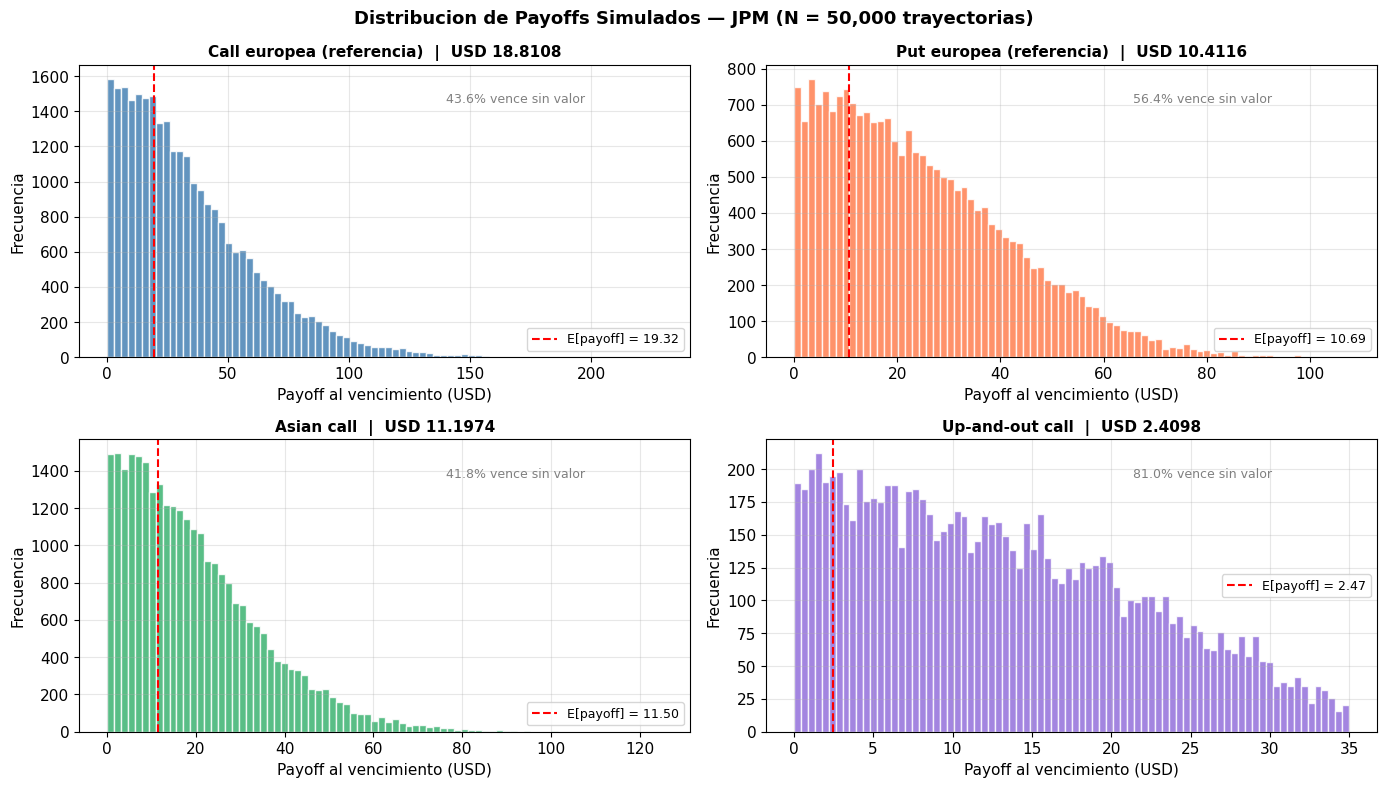

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

payoffs = [payoff_call, payoff_put, payoff_asian, payoff_barrier]
titulos = ['Call europea (referencia)', 'Put europea (referencia)',
           'Asian call', 'Up-and-out call']
colores = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
precios = [precio_call, precio_put, precio_asian, precio_barrier]

for i, (pf, titulo, color, precio) in enumerate(zip(payoffs, titulos, colores, precios)):
    ax = axes[i]
    positivos = pf[pf > 0]
    pct_cero  = np.mean(pf == 0) * 100
    if len(positivos) > 0:
        ax.hist(positivos, bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(pf), color='red', linestyle='--', linewidth=1.5,
               label=f'E[payoff] = {np.mean(pf):.2f}')
    ax.set_title(f'{titulo}  |  USD {precio:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Payoff al vencimiento (USD)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.text(0.60, 0.87, f'{pct_cero:.1f}% vence sin valor',
            transform=ax.transAxes, fontsize=9, color='gray')

fig.suptitle('Distribucion de Payoffs Simulados — JPM (N = 50,000 trayectorias)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Por qué son más baratas las opciones exóticas

**Asian call vs. Call europea**

La opción asiática usa el promedio del precio a lo largo de toda la trayectoria como base del payoff, no el precio final. Esto tiene una consecuencia directa: el promedio siempre es menos volátil que el precio en un punto específico. Si JPM estuvo plano los primeros meses y solo subió al final, el promedio será mucho menor que el precio final, y el payoff de la asiática será pequeño o incluso cero cuando la europea hubiera ganado bien.

En la simulación esto se ve en la distribución de payoffs: los de la asiática están más comprimidos hacia la izquierda y la cola derecha es considerablemente menos pronunciada. Hay más trayectorias donde el promedio no supera el strike, aunque el precio final sí lo haga. Esa compresión de los payoffs posibles es exactamente lo que hace que su precio sea menor.

**Up-and-out call vs. Call europea**

La barrera cancela la opción si en algún momento el precio de JPM toca o supera el nivel B. El problema es que los escenarios donde JPM sube mucho son precisamente los más valiosos para el comprador de una call. Con la barrera, muchos de esos escenarios se eliminan automáticamente — la opción se apaga en el camino aunque al final hubiera estado profundamente in-the-money.

En la simulación se puede ver que una fracción de las trayectorias tiene payoff exactamente cero por knockout, aunque en esos mismos escenarios la call europea hubiera generado una ganancia. Esa masa adicional de ceros en la distribución, que no existe en la call estándar, es lo que reduce el precio de la opción con barrera.